## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, Flatten, Reshape
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


## Load and Preprocess dataset

In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (_, _) = cifar10.load_data()

# Normalize to [0, 1]
x_train = x_train.astype('float32') / 255.

# For faster training/plotting, limit to 5000 samples
x_subset = x_train[:5000]
y_subset = y_train[:5000].flatten()

# Resize to match MobileNetV2 input
x_resized_subset = tf.image.resize(x_subset, [224, 224])
x_resized_subset = preprocess_input(x_resized_subset)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 100s 1us/step


## Autoencoder Definition & Training

In [3]:
def build_autoencoder():
    input_img = Input(shape=(32, 32, 3))

    # Encoder
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)  # Shape: (8, 8, 64)

    # Flatten for 2D latent space
    x = Flatten()(encoded)
    latent = Dense(2, name="latent_vector")(x)  # 2D latent space

    # Decoder
    x = Dense(8 * 8 * 64)(latent)
    x = Reshape((8, 8, 64))(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    return Model(input_img, decoded), Model(input_img, latent)

# Build and train
autoencoder, encoder = build_autoencoder()
autoencoder.compile(optimizer='adam', loss='mse')

# Train
autoencoder.fit(x_subset, x_subset, epochs=20, batch_size=128, shuffle=True, validation_split=0.1)


Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - loss: 0.0603 - val_loss: 0.0402
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0402 - val_loss: 0.0375
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0386 - val_loss: 0.0369
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0380 - val_loss: 0.0365
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0375 - val_loss: 0.0364
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0377 - val_loss: 0.0363
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0379 - val_loss: 0.0363
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0378 - val_loss: 0.0362
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0376 - val_loss: 0.0362
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0379 - val_loss: 0.0363
Epoch 11/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0376 - val_loss: 0.0360
Epoch 12/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.

## Feature Extraction (Autoencoder)

In [4]:
features_autoencoder = encoder.predict(x_subset)


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


## Feature Extraction (MobileNetv2)

In [5]:
mobilenet = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
features_mobilenet = mobilenet.predict(x_resized_subset)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step


## Dimensionality Reduction: PCA & t-SNE

In [6]:
# Reduce to 2D
pca = PCA(n_components=2)
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)

features_pca = pca.fit_transform(features_mobilenet)
features_tsne = tsne.fit_transform(features_mobilenet)


## Plotting Function and comparison plot

/tmp/ipython-input-13-183485345.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


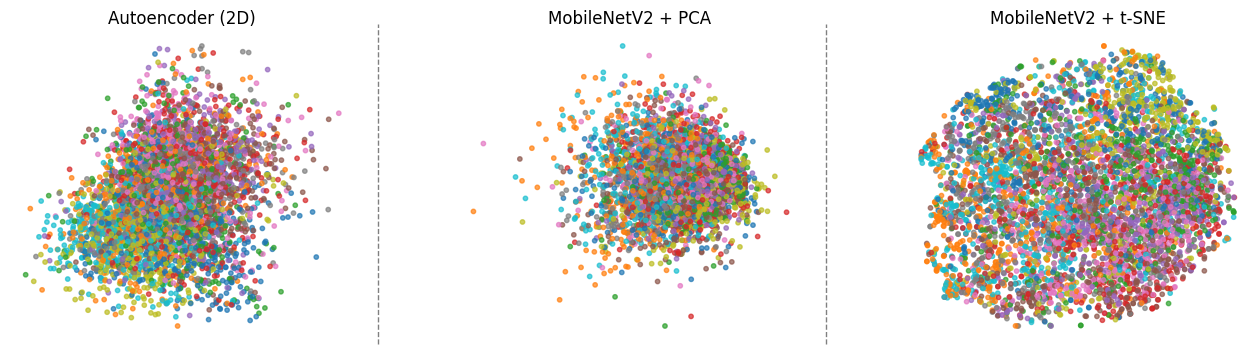

In [13]:
def plot_features(ax, features, labels, title):
    scatter = ax.scatter(features[:, 0], features[:, 1], c=labels, cmap='tab10', s=10, alpha=0.7)
    ax.set_title(title)
    ax.axis('off')

fig, axs = plt.subplots(1, 3, figsize=(16, 4), gridspec_kw={'wspace': 0.3})  # more spacing

plot_features(axs[0], features_autoencoder, y_subset, "Autoencoder (2D)")
plot_features(axs[1], features_pca, y_subset, "MobileNetV2 + PCA")
plot_features(axs[2], features_tsne, y_subset, "MobileNetV2 + t-SNE")

# Draw vertical lines between plots
for ax in axs[:-1]:
    bbox = ax.get_position()
    x = bbox.x1 + 0.015
    fig.add_artist(plt.Line2D([x, x], [0.1, 0.9], color='gray', linewidth=1, linestyle='--'))

plt.tight_layout()
plt.show()


## Denoising Autoencoder for CIFAR-10

In [14]:
# Add noise to CIFAR-10 images
def add_noise(images, noise_factor=0.2):
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy = np.clip(noisy, 0., 1.)
    return noisy

# Prepare noisy data
x_noisy = add_noise(x_subset)

# Define the denoising autoencoder
def build_denoising_autoencoder():
    input_img = Input(shape=(32, 32, 3))

    # Encoder
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    return Model(input_img, decoded)

# Build and compile
denoising_autoencoder = build_denoising_autoencoder()
denoising_autoencoder.compile(optimizer='adam', loss='mse')

# Train
denoising_autoencoder.fit(x_noisy, x_subset,  # Train on noisy → clean
                          epochs=20,
                          batch_size=64,
                          shuffle=True,
                          validation_split=0.1)


Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - loss: 0.0397 - val_loss: 0.0139
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0133 - val_loss: 0.0105
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0104 - val_loss: 0.0090
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0091 - val_loss: 0.0084
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0086 - val_loss: 0.0081
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0082 - val_loss: 0.0076
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0078 - val_loss: 0.0074
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0077 - val_loss: 0.0071
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0074 - val_loss: 0.0071
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0072 - val_loss: 0.0070
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0071 - val_loss: 0.0069
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0071 - val_l

## Visualize Denoising Results


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step


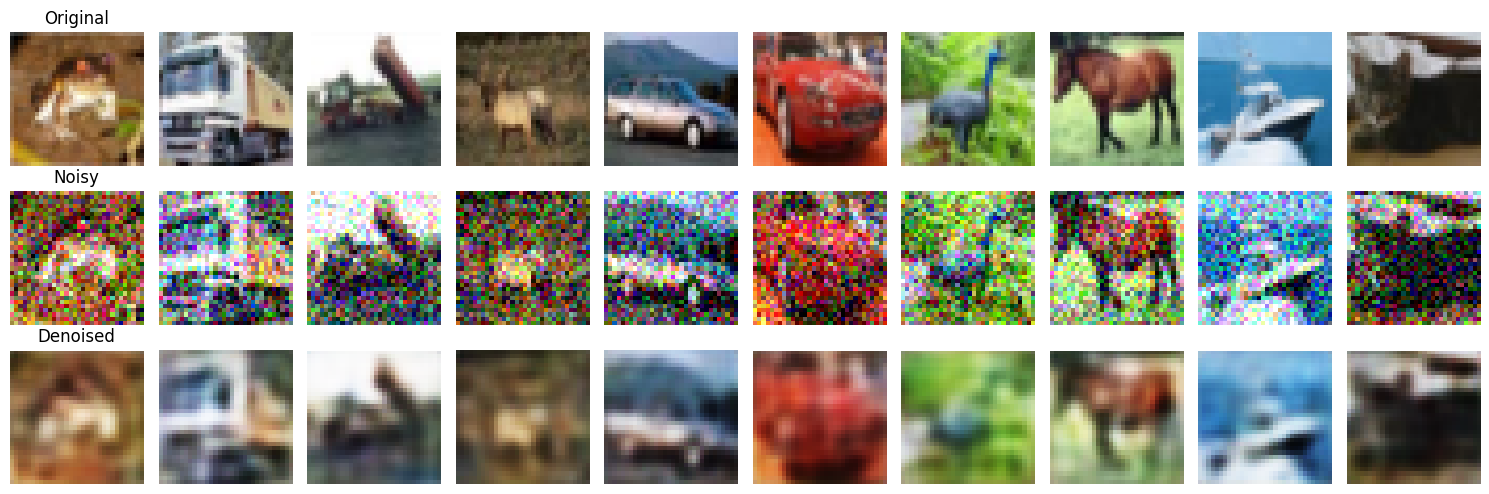

In [15]:
# Visualize original, noisy, and denoised output
decoded_imgs = denoising_autoencoder.predict(x_noisy[:10])

n = 10
plt.figure(figsize=(15, 5))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_subset[i])
    plt.axis("off")
    if i == 0: ax.set_title("Original")

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_noisy[i])
    plt.axis("off")
    if i == 0: ax.set_title("Noisy")

    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs[i])
    plt.axis("off")
    if i == 0: ax.set_title("Denoised")

plt.tight_layout()
plt.show()
